<a href="https://colab.research.google.com/github/jzazueta/data-science-business-econ/blob/main/notebooks/ch11_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 11 — Clustering: From Labels to Groups
### Companion Notebook

*Data Science for Business and Economics: A Python Approach* — Dr. Jorge Zazueta Gutiérrez

This notebook mirrors every code example in Chapter 11. Valeria Montemayor, a market-intelligence analyst at Bombas Cumbres, a Monterrey maker of industrial pumps and valves, looks for export markets that resemble Chile and Peru, using World Bank trade data for 130 economies.

Run the cells in order: later examples use objects built by earlier ones. Code Example 11.1 calls the live World Bank API; every other example reads the snapshot saved on 23 September 2026, so its output should match the book exactly. Cells marked as figure cells are not printed in the book; they draw the chapter's figures and save them to a `figures/` folder.

In [1]:
book_metadata = {
    "title": "Data Science for Business and Economics: A Python Approach",
    "chapter": 11,
    "chapter_title": "Clustering: From Labels to Groups",
    "author": "Jorge Zazueta Gutierrez",
    "protagonist": "Valeria Montemayor",
    "part": 2,
    "part_title": "Methods and Models",
    "requires": ["pandas", "numpy", "requests", "scipy",
                 "scikit-learn", "matplotlib", "seaborn"],
    "data": ["ch11_wdi_snapshot.csv", "ch11_wdi_raw_long.csv",
             "ch11_gold_production.csv"],
    "notebook_version": "0.1",
}
book_metadata

{'title': 'Data Science for Business and Economics: A Python Approach',
 'chapter': 11,
 'chapter_title': 'Clustering: From Labels to Groups',
 'author': 'Jorge Zazueta Gutierrez',
 'protagonist': 'Valeria Montemayor',
 'part': 2,
 'part_title': 'Methods and Models',
 'requires': ['pandas',
  'numpy',
  'requests',
  'scipy',
  'scikit-learn',
  'matplotlib',
  'seaborn'],
 'data': ['ch11_wdi_snapshot.csv',
  'ch11_wdi_raw_long.csv',
  'ch11_gold_production.csv'],
 'notebook_version': '0.1'}

## Setup: data files

The three data files live in the `data/` folder of the book's repository. This cell uses local copies when they exist and downloads them otherwise, so the notebook runs the same way in Colab and on your own machine.

In [2]:
# Data files: use local copies if present, otherwise download them
import os
import urllib.request

BASE = ("https://raw.githubusercontent.com/jzazueta/"
        "data-science-business-econ/main/data/")
for name in ["ch11_wdi_snapshot.csv", "ch11_wdi_raw_long.csv",
             "ch11_gold_production.csv"]:
    if not os.path.exists(name):
        urllib.request.urlretrieve(BASE + name, name)
    print(name, os.path.getsize(name), "bytes")

ch11_wdi_snapshot.csv 78378 bytes
ch11_wdi_raw_long.csv 1202327 bytes
ch11_gold_production.csv 786 bytes


## 11.1 Looking for Lookalike Markets

### 11.1.1 A Problem Without a Target

### 11.1.2 Valeria's Data

**Code Example 11.1** — Requesting one WDI indicator for Chile and Peru.

This cell calls the live World Bank API. If it fails because there is no connection, run the fallback cell below it instead.

In [ ]:
import requests
import pandas as pd

# Countries are separated by ";"; the indicator follows.
# TX.VAL.MMTL.ZS.UN: ores and metals, % of merchandise exports
url = ("https://api.worldbank.org/v2/country/CHL;PER/"
       "indicator/TX.VAL.MMTL.ZS.UN")
params = {"format": "json", "date": "2020:2024",
          "per_page": 100}
resp = requests.get(url, params=params, timeout=30)

# The JSON is a list: page information, then the data
page_info, rows = resp.json()
metals = pd.DataFrame(
    [{"iso3": r["countryiso3code"], "year": int(r["date"]),
      "value": r["value"]} for r in rows])

# One row per year, one column per country
print(metals.pivot(index="year", columns="iso3",
                   values="value").round(1))

*Offline fallback.* If the request above failed, this cell rebuilds the same table from the raw file written by the full pull. If the request worked, it does nothing.

In [4]:
# Offline fallback: rebuild the table from the saved raw pull
try:
    metals
except NameError:
    raw_long = pd.read_csv("ch11_wdi_raw_long.csv")
    keep = ((raw_long["indicator"] == "TX.VAL.MMTL.ZS.UN")
            & raw_long["iso3"].isin(["CHL", "PER"])
            & raw_long["year"].between(2020, 2024))
    metals = raw_long[keep]
    print(metals.pivot(index="year", columns="iso3",
                       values="value").round(1))

iso3   CHL   PER
year            
2020  57.4  43.5
2021  62.2  47.8
2022  49.8  43.1
2023  52.0  51.3
2024  56.1  47.8


**Code Example 11.2** — Loading the WDI snapshot.

In [5]:
import numpy as np

# One row per economy: the latest value of each indicator,
# and in the yr_ columns the year that value comes from
wdi = pd.read_csv("ch11_wdi_snapshot.csv")
print(wdi.shape)
print(wdi[["iso3", "country", "exp_ores_metals",
           "yr_exp_ores_metals"]].head(3))

(217, 33)
  iso3      country  exp_ores_metals  yr_exp_ores_metals
0  ABW        Aruba         6.765718              2023.0
1  AFG  Afghanistan         2.199921              2019.0
2  AGO       Angola         4.356886              2024.0


**Code Example 11.3** — Building the analysis sample.

In [6]:
# Ten indicators of trade structure and two of size
structure = ["exp_food", "exp_agri_raw", "exp_fuel",
             "exp_ores_metals", "exp_manuf", "hightech_share",
             "imp_fuel", "imp_manuf",
             "exports_gdp", "imports_gdp"]
size = ["gdp_usd", "gdp_pc_usd"]

# Economies of at least one million people
sample = wdi[wdi["population"] >= 1_000_000].copy()
print(len(sample))

# Treat any value older than 2019 as missing
for col in structure + size:
    too_old = sample["yr_" + col] < 2019
    sample.loc[too_old, col] = np.nan

# Keep complete rows, indexed by the three-letter country code
sample = (sample.dropna(subset=structure + size)
                .set_index("iso3"))
print(len(sample))
print(sample.loc[["CHL", "PER", "MEX"], structure].round(1).T)

160
130
iso3              CHL   PER   MEX
exp_food         22.9  21.2   8.5
exp_agri_raw      5.3   0.6   0.1
exp_fuel          1.3   5.7   4.5
exp_ores_metals  56.1  47.8   2.1
exp_manuf        13.1   7.4  79.0
hightech_share    8.3   5.2  19.3
imp_fuel         18.9  16.4   6.2
imp_manuf        66.0  68.2  75.6
exports_gdp      33.7  28.9  37.3
imports_gdp      30.2  22.8  38.1


## 11.2 Distance and the Scaling Trap

**Code Example 11.4** — Chile's nearest neighbors on the raw variables.

In [7]:
X = sample[structure + size]

# Distance from Chile: square each difference, add them up
# across the twelve variables, take the square root
diff = X - X.loc["CHL"]
dist_raw = np.sqrt((diff ** 2).sum(axis=1))

# The six economies closest to Chile (Chile itself is at zero)
nearest = dist_raw.drop("CHL").nsmallest(6).index
cols = ["country", "gdp_usd", "exp_ores_metals"]
view = sample.loc[nearest, cols]
view["gdp_usd"] = (view["gdp_usd"] / 1e9).round(0)  # US$ bn
print(view.round(1))

         country  gdp_usd  exp_ores_metals
iso3                                      
PRT     Portugal    314.0              2.6
CZE      Czechia    347.0              1.4
FIN      Finland    299.0              8.0
PER         Peru    292.0             47.8
KAZ   Kazakhstan    291.0             15.5
PAK     Pakistan    372.0              4.3


### 11.2.1 Why GDP Wins

**Code Example 11.5** — How much each variable contributes to the spread.

In [8]:
# Share of the total variance contributed by each variable
var_share = X.var() / X.var().sum() * 100   # percent of total
print(var_share.sort_values(ascending=False).head(3)
      .map("{:.5f}".format))

# Standard deviations in each variable's own units
print(X[["exp_ores_metals", "gdp_pc_usd", "gdp_usd"]].std()
      .map("{:,.1f}".format))

gdp_usd        100.00000
gdp_pc_usd       0.00000
exports_gdp      0.00000
dtype: str
exp_ores_metals                   15.1
gdp_pc_usd                    24,511.7
gdp_usd            3,106,262,400,994.7
dtype: str


### 11.2.2 Standardizing

**Code Example 11.6** — Standardizing and recomputing Chile's neighbors.

In [9]:
from sklearn.preprocessing import StandardScaler

# Rescale every column to mean 0 and standard deviation 1
scaler = StandardScaler()
Z = pd.DataFrame(scaler.fit_transform(X),
                 index=X.index, columns=X.columns)
check = Z[["exp_ores_metals", "gdp_usd"]]
print(check.agg(["mean", "std"]).round(2))

# Distances from Chile again, now in standardized units
dist_std = np.sqrt(((Z - Z.loc["CHL"]) ** 2).sum(axis=1))
print(dist_std.drop("CHL").nsmallest(6).round(2))

      exp_ores_metals  gdp_usd
mean              0.0      0.0
std               1.0      1.0
iso3
PER    1.22
ZMB    1.85
BOL    2.00
ZWE    2.08
MDG    2.17
ZAF    2.28
dtype: float64


*Figure setup.* Plotting libraries and the book's palette, used by the figure cells below.

In [10]:
# Figure setup: plotting libraries, theme and the base palette
import os
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

sns.set_theme(style="whitegrid", context="notebook")
BLUE = "#4682B4"                       # the book's base accent color
CLUSTER_COLORS = {"Manufactures": "#4682B4", "Fuel": "#C8963E",
                  "Metals": "#6A9F58", "Food": "#B5533C"}
os.makedirs("figures", exist_ok=True)  # figures are saved here too

*Figure 11.1* (not printed in the book).

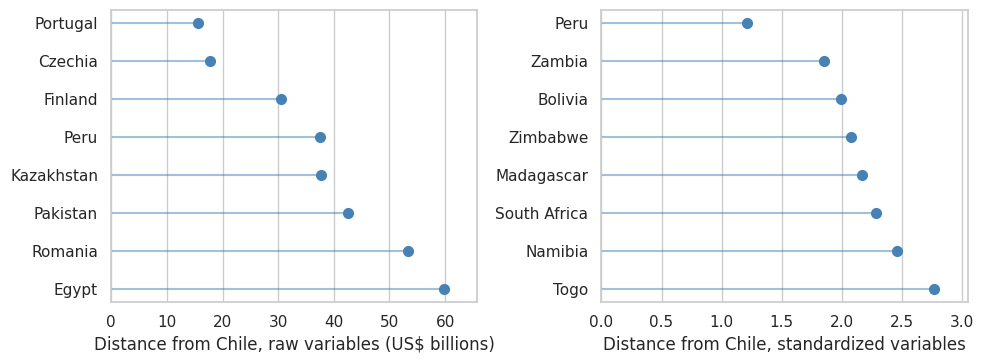

In [11]:
# Figure 11.1: Chile's eight nearest neighbors, raw vs standardized
Z12 = pd.DataFrame(StandardScaler().fit_transform(X),
                   index=X.index, columns=X.columns)
raw8 = (np.sqrt(((X - X.loc["CHL"]) ** 2).sum(axis=1))
        .drop("CHL").nsmallest(8) / 1e9)          # US$ billions
std8 = (np.sqrt(((Z12 - Z12.loc["CHL"]) ** 2).sum(axis=1))
        .drop("CHL").nsmallest(8))
nicer = {"Congo, Dem. Rep.": "DR Congo", "Egypt, Arab Rep.": "Egypt"}

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
panels = [(axes[0], raw8,
           r"Distance from Chile, raw variables (US\$ billions)"),
          (axes[1], std8, "Distance from Chile, standardized variables")]
for ax, dist, xlabel in panels:
    y = np.arange(len(dist))[::-1]              # closest at the top
    ax.hlines(y, 0, dist.values, color=BLUE, lw=1.5, alpha=0.5)
    ax.plot(dist.values, y, "o", color=BLUE, ms=7)
    ax.set_yticks(y)
    ax.set_yticklabels(sample.loc[dist.index, "country"].replace(nicer))
    ax.set_xlabel(xlabel)
    ax.set_xlim(0, dist.max() * 1.1)
    ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.savefig("figures/fig11_1_chile_neighbors.png", dpi=200)
plt.show()

### 11.2.3 Resemblance and Size are Separate Questions

**Code Example 11.7** — Distances on the ten structural indicators.

In [12]:
# Standardize the ten structural indicators only
scaled = StandardScaler().fit_transform(sample[structure])
Zs = pd.DataFrame(scaled, index=sample.index,
                  columns=structure)
dist_struct = np.sqrt(((Zs - Zs.loc["CHL"]) ** 2).sum(axis=1))
print(dist_struct.drop("CHL").nsmallest(6).round(2))

# Where the size-based neighbors now rank among the 129 others
rank = dist_struct.drop("CHL").rank()
print(rank.loc[["PRT", "CZE", "FIN"]].astype(int))

iso3
PER    1.17
ZMB    1.74
BOL    1.93
ZWE    1.99
MDG    2.07
ZAF    2.24
dtype: float64
iso3
PRT     54
CZE    115
FIN     27
dtype: int64


### 11.2.4 Other Ways to Measure Distance

**Code Example 11.8** — Chile's nearest neighbors under four distances.

In [13]:
from scipy.spatial.distance import cdist

# Distance from Chile under four metrics
metrics = ["euclidean", "cityblock", "chebyshev", "cosine"]
chile = Zs.loc[["CHL"]]
for m in metrics:
    d = pd.Series(cdist(chile, Zs, metric=m)[0],
                  index=Zs.index)
    nearest6 = d.drop("CHL").nsmallest(6).index.tolist()
    print(f"{m:10s}", nearest6)

euclidean  ['PER', 'ZMB', 'BOL', 'ZWE', 'MDG', 'ZAF']
cityblock  ['PER', 'ZMB', 'ZWE', 'BOL', 'ZAF', 'MDG']
chebyshev  ['PER', 'ZMB', 'BOL', 'AUS', 'ZWE', 'MDG']
cosine     ['ZMB', 'PER', 'BOL', 'ZAF', 'MDG', 'ZWE']


**Code Example 11.9** — Export similarity with Chile from the Manhattan distance on raw shares.

In [14]:
shares = ["exp_food", "exp_agri_raw", "exp_fuel",
          "exp_ores_metals", "exp_manuf"]
basket = sample[shares].copy()

# Whatever the five groups leave out, so each row sums to 100
# (clipped at zero where rounding pushes the five past 100)
basket["exp_other"] = (100 - basket.sum(axis=1)).clip(lower=0)

# Half the Manhattan distance: percent of exports that differ
diff_pct = cdist(basket.loc[["CHL"]], basket,
                 metric="cityblock")[0] / 2
similarity = pd.Series(100 - diff_pct, index=basket.index)
print(similarity.drop("CHL").nlargest(6).round(1))
print(similarity.loc[["PRT", "MEX"]].round(1))

iso3
CUB    87.8
ZMB    80.7
PER    79.6
BHR    78.4
TJK    77.7
BOL    75.9
dtype: float64
iso3
PRT    33.9
MEX    26.3
dtype: float64


## 11.3 K-Means Clustering

### 11.3.1 The Algorithm

### 11.3.2 The Scaling Trap, Clustered

**Code Example 11.10** — K-means on the twelve raw variables.

In [15]:
from sklearn.cluster import KMeans

# K-means with four clusters on the twelve raw variables
km_raw = KMeans(n_clusters=4, n_init=50, random_state=0)
raw_labels = km_raw.fit_predict(X)

# Size and GDP range of each cluster, GDP in US$ billions
gdp_bn = sample["gdp_usd"] / 1e9
stats = ["count", "min", "max"]
summary = gdp_bn.groupby(raw_labels).agg(stats)
print(summary.round(0))

   count      min      max
0    115      2.0   1396.0
1      1  29298.0  29298.0
2      1  18730.0  18730.0
3     13   1726.0   4686.0


### 11.3.3 A First Pass on Ten Indicators

**Code Example 11.11** — Average silhouette for the first pass.

In [16]:
from sklearn.metrics import silhouette_score

# First pass: all ten standardized structural indicators
for k in range(2, 9):
    labels = KMeans(n_clusters=k, n_init=50,
                    random_state=0).fit_predict(Zs)
    print(k, round(silhouette_score(Zs, labels), 3))

# Size of Chile's cluster when k = 4
labels10 = KMeans(n_clusters=4, n_init=50,
                  random_state=0).fit_predict(Zs)
chile_c = labels10[sample.index.get_loc("CHL")]
n_chile = (labels10 == chile_c).sum()
print("Chile's cluster:", n_chile, "economies")

2 0.193


3 0.238


4 0.24
5 0.26
6 0.262


7 0.255


8 0.213


Chile's cluster: 55 economies


### 11.3.4 Similar for What?

### 11.3.5 A Second Pass on the Export Basket

**Code Example 11.12** — Inertia and silhouette on the four export shares.

In [17]:
basket4 = ["exp_food", "exp_fuel",
           "exp_ores_metals", "exp_manuf"]
scaled4 = StandardScaler().fit_transform(sample[basket4])
Z4 = pd.DataFrame(scaled4, index=sample.index,
                  columns=basket4)

# Inertia (within-cluster sum of squares) and silhouette by k
for k in range(1, 9):
    km = KMeans(n_clusters=k, n_init=50,
                random_state=0).fit(Z4)
    if k > 1:
        sil = silhouette_score(Z4, km.labels_)
    else:
        sil = np.nan
    print(k, round(km.inertia_, 1), round(sil, 3))

1 520.0 nan
2 359.4 0.355
3 224.5 0.476
4 120.8 0.556
5 95.5 0.47


6 82.8 0.465


7 70.4 0.472


8 60.4 0.449


*Figure 11.2* (not printed in the book).

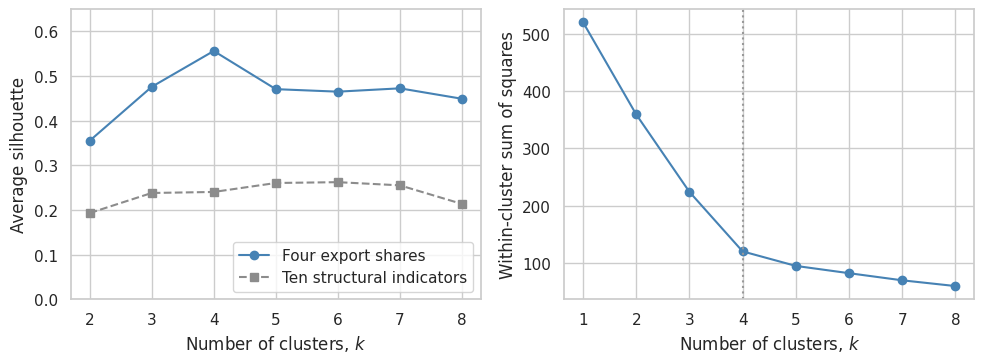

In [18]:
# Figure 11.2: silhouette by k for both passes, and the elbow
ks = range(2, 9)
sil4 = [silhouette_score(Z4, KMeans(n_clusters=k, n_init=50,
        random_state=0).fit_predict(Z4)) for k in ks]
sil10 = [silhouette_score(Zs, KMeans(n_clusters=k, n_init=50,
         random_state=0).fit_predict(Zs)) for k in ks]
inertia = [KMeans(n_clusters=k, n_init=50, random_state=0)
           .fit(Z4).inertia_ for k in range(1, 9)]

fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
ax[0].plot(ks, sil4, "o-", color=BLUE, label="Four export shares")
ax[0].plot(ks, sil10, "s--", color="0.55",
           label="Ten structural indicators")
ax[0].set_xlabel("Number of clusters, $k$")
ax[0].set_ylabel("Average silhouette")
ax[0].set_ylim(0, 0.65)
ax[0].legend(frameon=True, loc="lower right")
ax[1].plot(range(1, 9), inertia, "o-", color=BLUE)
ax[1].axvline(4, color="0.6", ls=":")
ax[1].set_xlabel("Number of clusters, $k$")
ax[1].set_ylabel("Within-cluster sum of squares")
plt.tight_layout()
plt.savefig("figures/fig11_2_choosing_k.png", dpi=200)
plt.show()

**Code Example 11.13** — Fitting four clusters and profiling them.

In [19]:
km4 = KMeans(n_clusters=4, n_init=50, random_state=0).fit(Z4)
sample["cluster"] = km4.labels_

# Median export shares within each cluster, in percent
profile = sample.groupby("cluster")[basket4].median().round(1)
profile["n"] = sample["cluster"].value_counts()
print(profile)

         exp_food  exp_fuel  exp_ores_metals  exp_manuf   n
cluster                                                    
0            21.6       2.7             43.6       13.1  15
1            11.5       4.5              2.8       70.0  66
2             4.1      65.5              3.8       11.6  23
3            50.2       1.5              2.2       17.5  26


**Code Example 11.14** — Naming the clusters and listing the metals group.

In [20]:
# Name each cluster after its largest median share
names = {"exp_food": "food", "exp_fuel": "fuel",
         "exp_ores_metals": "metals",
         "exp_manuf": "manufactures"}
top = profile[basket4].idxmax(axis=1).map(names)
sample["group"] = sample["cluster"].map(top)

import textwrap

metals = sample[sample["group"] == "metals"]
print(len(metals))
# Wrap the list of names at 60 characters for printing
listing = ", ".join(sorted(metals["country"]))
print(textwrap.fill(listing, width=60))
print(sample.loc[["MEX", "COL", "BRA", "NOR"], "group"])

15
Australia, Bahrain, Bolivia, Chile, Congo, Dem. Rep., Cuba,
Madagascar, Mauritania, Namibia, Peru, Rwanda, South Africa,
Tajikistan, Zambia, Zimbabwe
iso3
MEX    manufactures
COL            fuel
BRA            food
NOR            fuel
Name: group, dtype: str


*Figure 11.3* (not printed in the book).

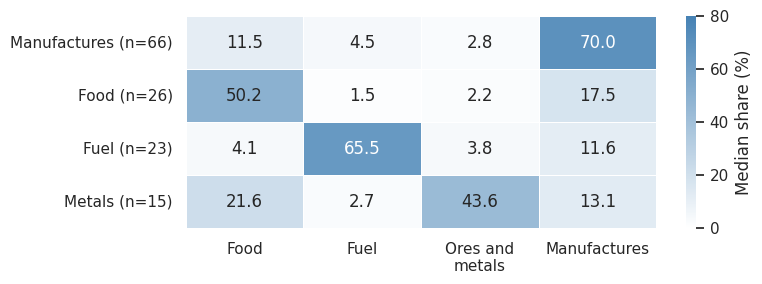

In [21]:
# Figure 11.3: median export shares by cluster, as a heatmap
cmap = LinearSegmentedColormap.from_list("steel", ["#ffffff", BLUE])
heat = profile[basket4].copy()
heat.index = [f"{top[i].capitalize()} (n={profile.loc[i, 'n']})"
              for i in heat.index]
order = [i for g in ["Manufactures", "Food", "Fuel", "Metals"]
         for i in heat.index if i.startswith(g)]
heat = heat.loc[order]
heat.columns = ["Food", "Fuel", "Ores and\nmetals", "Manufactures"]

fig, ax = plt.subplots(figsize=(8, 3.0))
sns.heatmap(heat, annot=True, fmt=".1f", cmap=cmap, vmin=0, vmax=80,
            cbar_kws={"label": "Median share (%)"},
            linewidths=0.5, linecolor="white", ax=ax)
ax.set_xlabel("")
ax.set_ylabel("")
plt.yticks(rotation=0)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("figures/fig11_3_cluster_profiles.png", dpi=200)
plt.show()

## 11.4 Hierarchical Clustering

### 11.4.1 Linkage

**Code Example 11.15** — Ward linkage compared with K-means.

In [22]:
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import adjusted_rand_score

# Ward linkage on the four standardized export shares
tree = linkage(Z4, method="ward")

# Cut the tree into four clusters and compare with K-means
ward4 = fcluster(tree, t=4, criterion="maxclust")
print(pd.crosstab(sample["group"], ward4))
print(round(adjusted_rand_score(sample["cluster"], ward4), 2))

col_0          1   2   3   4
group                       
food           0   0   0  26
fuel           0  23   0   0
manufactures  66   0   0   0
metals         0   0  15   0
1.0


### 11.4.2 Reading the Dendrogram

**Code Example 11.16** — The heights of the last merges.

In [23]:
# Each row of the tree records one merge: the two clusters
# joined, the height of the merge, and the size of the result.
# The last six merges, from lowest to highest:
print(tree[-6:, 2].round(2))

[ 5.19  5.23  6.05 14.5  16.82 17.47]


*Figure 11.4* (not printed in the book).

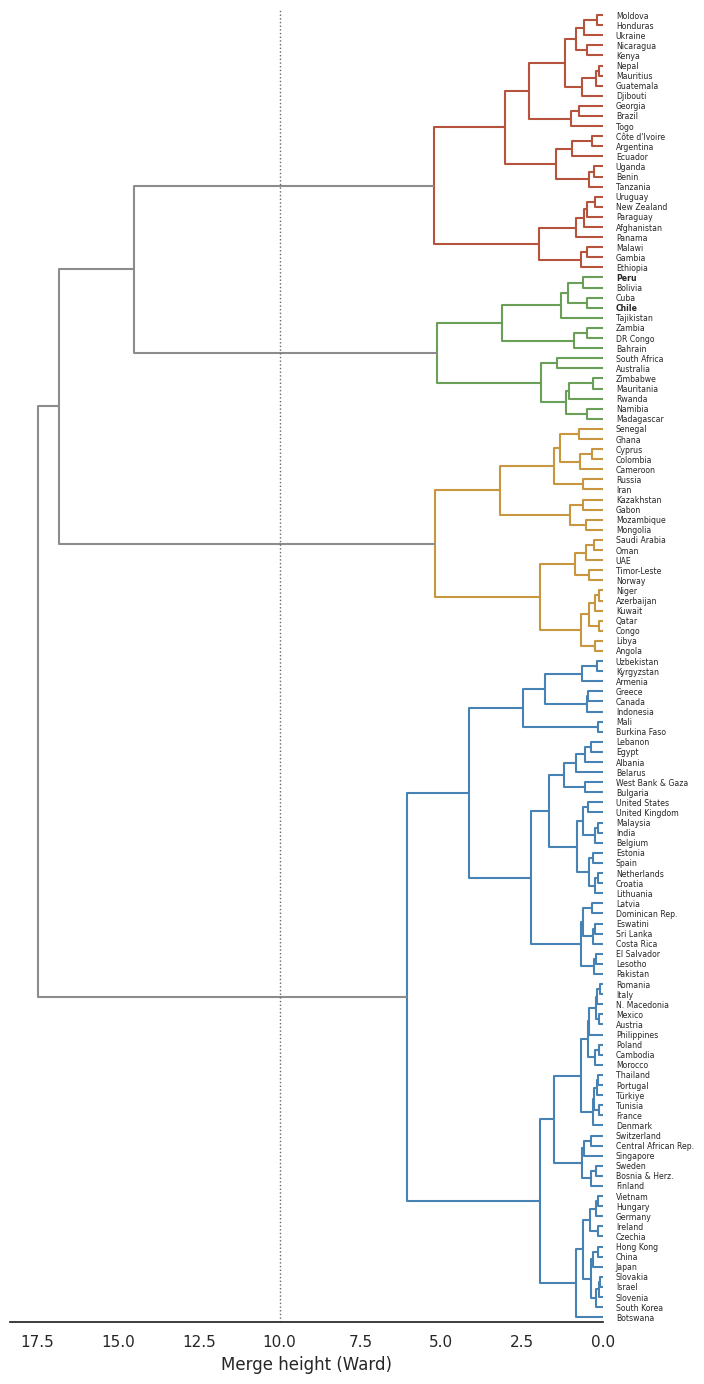

In [24]:
# Figure 11.4: the Ward dendrogram, one leaf per economy
from scipy.cluster.hierarchy import dendrogram, set_link_color_palette

short = {"Congo, Dem. Rep.": "DR Congo", "Egypt, Arab Rep.": "Egypt",
         "Iran, Islamic Rep.": "Iran", "Korea, Rep.": "South Korea",
         "Venezuela, RB": "Venezuela", "Yemen, Rep.": "Yemen",
         "Russian Federation": "Russia", "Lao PDR": "Laos",
         "Kyrgyz Republic": "Kyrgyzstan", "Slovak Republic": "Slovakia",
         "Turkiye": "T\u00fcrkiye", "Viet Nam": "Vietnam",
         "Hong Kong SAR, China": "Hong Kong",
         "West Bank and Gaza": "West Bank & Gaza",
         "Gambia, The": "Gambia", "Congo, Rep.": "Congo",
         "Syrian Arab Republic": "Syria",
         "Cote d'Ivoire": "C\u00f4te d'Ivoire",
         "Bosnia and Herzegovina": "Bosnia & Herz.",
         "North Macedonia": "N. Macedonia",
         "Dominican Republic": "Dominican Rep.",
         "Trinidad and Tobago": "Trinidad & Tobago",
         "Papua New Guinea": "Papua N. Guinea",
         "United Arab Emirates": "UAE",
         "Central African Republic": "Central African Rep."}
leaf_names = [short.get(c, c) for c in sample["country"]]

sns.set_theme(style="white", context="notebook")
set_link_color_palette(["#4682B4", "#C8963E", "#6A9F58", "#B5533C"])
fig, ax = plt.subplots(figsize=(7.2, 14))
dendrogram(tree, orientation="left", labels=leaf_names,
           color_threshold=10, above_threshold_color="0.55",
           leaf_font_size=5.6, ax=ax)
ax.axvline(10, color="0.4", ls=":", lw=1)   # the cut at four clusters
ax.set_xlabel("Merge height (Ward)")
for side in ["top", "right", "left"]:
    ax.spines[side].set_visible(False)
for label in ax.get_yticklabels():
    if label.get_text() in ("Chile", "Peru"):
        label.set_fontweight("bold")
plt.tight_layout()
plt.savefig("figures/fig11_4_dendrogram.png", dpi=220)
plt.show()
sns.set_theme(style="whitegrid", context="notebook")

### 11.4.3 Clustering with a Different Distance

**Code Example 11.17** — Average linkage on the export-dissimilarity distance.

In [25]:
from scipy.spatial.distance import pdist, squareform

# Export dissimilarity for every pair: half of Manhattan
d_export = pdist(basket, metric="cityblock") / 2
tree_avg = linkage(d_export, method="average")

# Silhouettes computed from the same distances
D = squareform(d_export)
for k in range(3, 9):
    lab = fcluster(tree_avg, t=k, criterion="maxclust")
    sil = silhouette_score(D, lab, metric="precomputed")
    print(k, round(sil, 3))

3 0.402
4 0.408
5 0.493
6 0.474
7 0.477
8 0.449


**Code Example 11.18** — Profiles of the five average-linkage clusters.

In [26]:
avg5 = fcluster(tree_avg, t=5, criterion="maxclust")
sample["avg5"] = avg5

# Median shares per cluster, with short column names
short = ["food", "agri", "fuel", "metals", "manuf", "other"]
prof5 = basket.groupby(avg5).median().round(1)
prof5.columns = short
prof5["n"] = sample["avg5"].value_counts()
print(prof5)

   food  agri  fuel  metals  manuf  other   n
1   6.0   0.6  60.0     4.8   14.4    0.9  26
2  11.5   0.9   4.0     2.7   72.7    2.0  57
3  50.9   2.1   1.3     2.3   30.5    0.3  25
4  15.0   0.8   4.2    54.8   13.6    1.1   8
5  19.8   1.2   2.3     6.9   12.1   41.0  14


**Code Example 11.19** — Members of the metals and "other" clusters.

In [27]:
# Name each cluster after its largest median share
top5 = prof5[short].idxmax(axis=1)
sample["group5"] = sample["avg5"].map(top5)

for g in ["metals", "other"]:
    members = sample.loc[sample["group5"] == g, "country"]
    print(g, len(members))
    print(textwrap.fill(", ".join(sorted(members)), width=60))
print(sample.loc[["AUS", "ZAF", "MDG"], ["group", "group5"]])

metals 8
Bahrain, Bolivia, Chile, Congo, Dem. Rep., Cuba, Peru,
Tajikistan, Zambia
other 14
Argentina, Armenia, Belarus, Burkina Faso, Ghana, Kyrgyz
Republic, Mali, Mauritania, Namibia, Rwanda, Tanzania,
Uganda, Uzbekistan, Zimbabwe
       group group5
iso3               
AUS   metals   fuel
ZAF   metals   food
MDG   metals   food


**Code Example 11.20** — K-means on the six complete-basket shares.

In [28]:
# K-means on all six shares, standardized, with five clusters
scaled6 = StandardScaler().fit_transform(basket)
km6 = KMeans(n_clusters=5, n_init=50,
             random_state=0).fit_predict(scaled6)
print(round(adjusted_rand_score(avg5, km6), 2))

0.87


## 11.5 Principal Components

### 11.5.1 Directions of Greatest Variation

**Code Example 11.21** — Principal components of the four standardized export shares.

In [29]:
from sklearn.decomposition import PCA

# All four components of the standardized export shares
pca = PCA().fit(Z4)
print(pca.explained_variance_ratio_.round(3))
print(pca.explained_variance_ratio_.cumsum().round(3))

[0.386 0.33  0.258 0.026]
[0.386 0.716 0.974 1.   ]


**Code Example 11.22** — Loadings of the four components.

In [30]:
# Loadings: the weight of each share in each component
loadings = pd.DataFrame(pca.components_.T, index=basket4,
                        columns=["PC1", "PC2", "PC3", "PC4"])
print(loadings.round(2))

                  PC1   PC2   PC3   PC4
exp_food        -0.06  0.78 -0.41  0.47
exp_fuel        -0.55 -0.55 -0.34  0.54
exp_ores_metals -0.37  0.20  0.84  0.35
exp_manuf        0.75 -0.24  0.14  0.60


### 11.5.2 Why the Fourth Component Is Small

**Code Example 11.23** — What the fourth component measures.

In [31]:
# The fourth component and the total of the four shares
pc4 = pd.Series(pca.transform(Z4)[:, 3], index=Z4.index)
total4 = sample[basket4].sum(axis=1)
print(round(pc4.corr(total4), 3))
lowest = sample.loc[pc4.nsmallest(8).index, "country"]
print(textwrap.fill(", ".join(lowest), width=60))

0.977
Burkina Faso, Mali, Benin, Ghana, Uzbekistan, Armenia,
Tanzania, Uganda


### 11.5.3 Seeing the Clusters

**Code Example 11.24** — Average component scores by cluster.

In [32]:
# Coordinates of every economy on the first three components
first3 = pca.transform(Z4)[:, :3]
scores = pd.DataFrame(first3, index=Z4.index,
                      columns=["PC1", "PC2", "PC3"])
scores["group"] = sample["group"]
print(scores.groupby("group").mean().round(2))

               PC1   PC2   PC3
group                         
food         -0.20  1.69 -0.91
fuel         -1.72 -1.38 -0.70
manufactures  0.99 -0.37  0.13
metals       -1.37  0.83  2.09


*Figure 11.5* (not printed in the book).

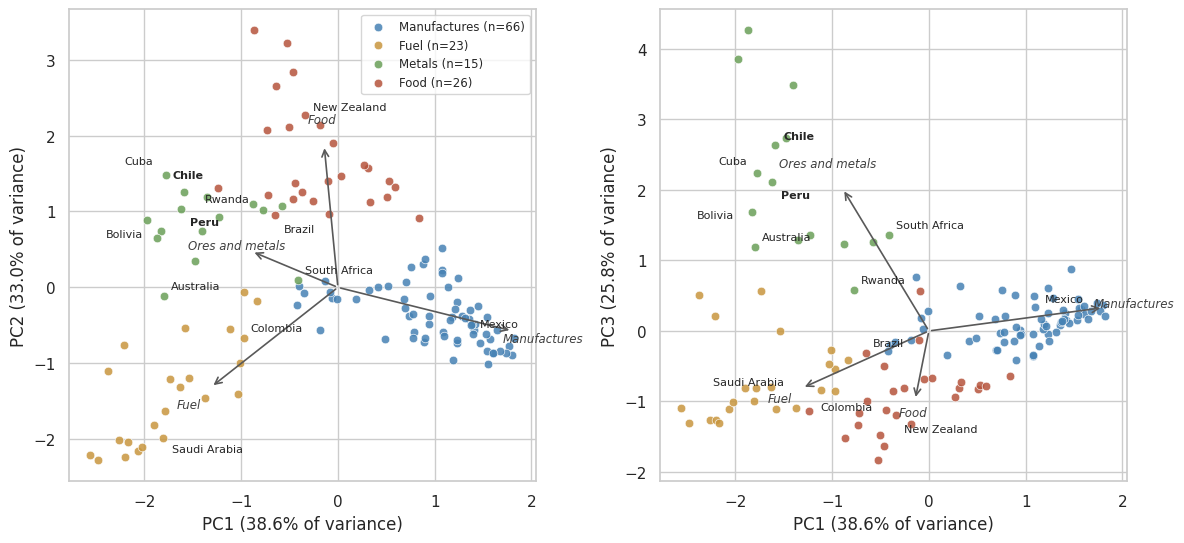

In [33]:
# Figure 11.5: clusters on PC1-PC2 and PC1-PC3, with loading arrows
P = pd.DataFrame(pca.transform(Z4)[:, :3], index=Z4.index,
                 columns=["PC1", "PC2", "PC3"])
P["Cluster"] = sample["group"].str.capitalize()
ev = pca.explained_variance_ratio_ * 100
tags = {"CHL": "Chile", "PER": "Peru", "CUB": "Cuba", "AUS": "Australia",
        "ZAF": "South Africa", "BOL": "Bolivia", "RWA": "Rwanda",
        "MEX": "Mexico", "SAU": "Saudi Arabia", "COL": "Colombia",
        "BRA": "Brazil", "NZL": "New Zealand"}
arrow_names = ["Food", "Fuel", "Ores and metals", "Manufactures"]
offsets = {"PC2": {"CHL": (-8, 10), "PER": (6, -12), "CUB": (-30, 8),
                   "BOL": (-40, -4), "SAU": (6, -10), "NZL": (6, 4),
                   "RWA": (-42, 6), "BRA": (6, -12)},
           "PC3": {"CHL": (6, 4), "PER": (6, -12), "CUB": (-28, 6),
                   "BOL": (-40, -4), "SAU": (-30, 12), "NZL": (6, -12),
                   "COL": (-10, -14), "MEX": (-14, 12)}}

fig, axes = plt.subplots(1, 2, figsize=(12, 5.6))
for ax, pc in zip(axes, ["PC2", "PC3"]):
    j = int(pc[-1]) - 1
    for name, color in CLUSTER_COLORS.items():
        d = P[P["Cluster"] == name]
        ax.scatter(d["PC1"], d[pc], s=38, color=color, alpha=0.85,
                   edgecolor="white", lw=0.5,
                   label=f"{name} (n={len(d)})")
    # Loading arrows, scaled so they are visible next to the scores
    for lab, lx, ly in zip(arrow_names, pca.components_[0] * 2.4,
                           pca.components_[j] * 2.4):
        ax.annotate("", xy=(lx, ly), xytext=(0, 0),
                    arrowprops=dict(arrowstyle="->", color="0.35", lw=1.2))
        ax.text(lx * 1.18, ly * 1.18, lab, color="0.25", fontsize=8.5,
                ha="center", va="center", style="italic")
    for iso, name in tags.items():
        ax.annotate(name, (P.loc[iso, "PC1"], P.loc[iso, pc]),
                    xytext=offsets[pc].get(iso, (5, 5)),
                    textcoords="offset points", fontsize=8,
                    fontweight="bold" if iso in ("CHL", "PER") else "normal")
    ax.set_xlabel(f"PC1 ({ev[0]:.1f}% of variance)")
    ax.set_ylabel(f"{pc} ({ev[j]:.1f}% of variance)")
axes[0].legend(loc="upper right", fontsize=8.5, frameon=True)
plt.tight_layout()
plt.savefig("figures/fig11_5_pca_clusters.png", dpi=200)
plt.show()

**Code Example 11.25** — Clustering on the first three components.

In [34]:
# K-means on the first three components only
pcs = scores[["PC1", "PC2", "PC3"]]
km_pc3 = KMeans(n_clusters=4, n_init=50,
                random_state=0).fit_predict(pcs)
ari_pc3 = adjusted_rand_score(sample["cluster"], km_pc3)
print(round(ari_pc3, 2))

# First pass for comparison: PCA on the ten indicators
pca10 = PCA().fit(Zs)
print(pca10.explained_variance_ratio_[:3].cumsum().round(3))

1.0
[0.318 0.474 0.616]


## 11.6 Is the Structure Real?

### 11.6.1 Clusters From Shuffled Data

**Code Example 11.26** — Silhouettes of K-means on shuffled data.

In [35]:
rng = np.random.default_rng(42)

def null_silhouettes(Z, k, n_shuffles=50):
    """K-means silhouettes on column-shuffled data."""
    values = []
    for r in range(n_shuffles):
        # Shuffle each column separately: same values,
        # random pairing across economies
        cols = [rng.permutation(Z.iloc[:, j].to_numpy())
                for j in range(Z.shape[1])]
        shuffled = np.column_stack(cols)
        lab = KMeans(n_clusters=k, n_init=10,
                     random_state=r).fit_predict(shuffled)
        values.append(silhouette_score(shuffled, lab))
    return np.array(values)

null4 = null_silhouettes(Z4, k=4)
null10 = null_silhouettes(Zs, k=4)
print("four shares:", null4.mean().round(3),
      null4.max().round(3))
print("ten indicators:", null10.mean().round(3),
      null10.max().round(3))

# For comparison: normal random numbers, no skew and no groups
normal = pd.DataFrame(rng.normal(size=Z4.shape))
null_normal = null_silhouettes(normal, k=4)
print("normal noise:", null_normal.mean().round(3),
      null_normal.max().round(3))

four shares: 0.358 0.396
ten indicators: 0.12 0.186


normal noise: 0.2 0.22


*Figure 11.6* (not printed in the book).

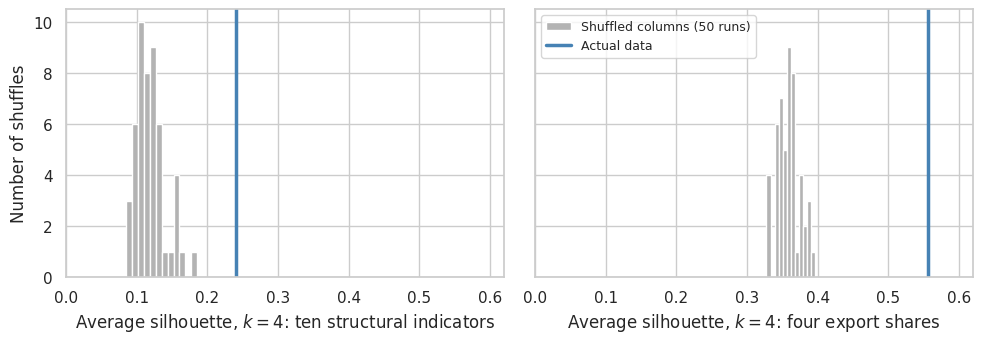

In [36]:
# Figure 11.6: silhouettes on shuffled data vs the actual data
obs10 = silhouette_score(Zs, labels10)
obs4 = silhouette_score(Z4, sample["cluster"])

fig, ax = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True)
panels = [(ax[0], null10, obs10, "ten structural indicators"),
          (ax[1], null4, obs4, "four export shares")]
for a, null, obs, what in panels:
    a.hist(null, bins=12, color="0.7", edgecolor="white",
           label="Shuffled columns (50 runs)")
    a.axvline(obs, color=BLUE, lw=2.5, label="Actual data")
    a.set_xlim(0, 0.62)
    a.set_xlabel(f"Average silhouette, $k=4$: {what}")
ax[0].set_ylabel("Number of shuffles")
ax[1].legend(loc="upper left", frameon=True, fontsize=9)
plt.tight_layout()
plt.savefig("figures/fig11_6_permutation_null.png", dpi=200)
plt.show()

**Code Example 11.27** — How lopsided the export shares are.

In [37]:
# Share of economies below 5 percent, and skewness, per share
print((sample[basket4] < 5).mean().round(2))
print(sample[basket4].skew().round(2))

exp_food           0.19
exp_fuel           0.50
exp_ores_metals    0.62
exp_manuf          0.08
dtype: float64
exp_food           1.50
exp_fuel           1.88
exp_ores_metals    2.66
exp_manuf          0.10
dtype: float64


### 11.6.2 Do the Clusters Come Back?

**Code Example 11.28** — Bootstrap reproducibility of the two passes.

In [38]:
def bootstrap_labels(X, k, n_boot=200, seed=0):
    """Refit K-means on bootstrap samples; label all."""
    rng_b = np.random.default_rng(seed)
    out = np.empty((n_boot, len(X)), dtype=int)
    for b in range(n_boot):
        # Draw economies with replacement, same sample size
        idx = rng_b.choice(len(X), size=len(X), replace=True)
        scaler = StandardScaler().fit(X.iloc[idx])
        km = KMeans(n_clusters=k, n_init=10, random_state=b)
        km.fit(scaler.transform(X.iloc[idx]))
        # Assign all 130 economies to the new centroids
        out[b] = km.predict(scaler.transform(X))
    return out

boot4 = bootstrap_labels(sample[basket4], k=4)
boot10 = bootstrap_labels(sample[structure], k=4)
ari4 = [adjusted_rand_score(sample["cluster"], r)
        for r in boot4]
ari10 = [adjusted_rand_score(labels10, r) for r in boot10]
print("four shares:", np.mean(ari4).round(2),
      np.percentile(ari4, 5).round(2))
print("ten indicators:", np.mean(ari10).round(2),
      np.percentile(ari10, 5).round(2))

four shares: 0.97 0.91
ten indicators: 0.75 0.52


### 11.6.3 Which Economies Stay With Chile

**Code Example 11.29** — How often each economy clusters with Chile.

In [39]:
# Share of bootstrap fits that put each economy with Chile
chile_pos = sample.index.get_loc("CHL")
same = (boot4 == boot4[:, [chile_pos]]).mean(axis=0)
together = pd.Series(same, index=sample.index).drop("CHL")
print(together[together > 0.02].sort_values(ascending=False)
      .round(2).to_string())

iso3
BHR    1.00
BOL    1.00
COD    1.00
CUB    1.00
ZMB    1.00
TJK    1.00
PER    1.00
MRT    1.00
ZWE    1.00
NAM    0.99
MDG    0.98
AUS    0.98
ZAF    0.95
RWA    0.62
TGO    0.15


*Figure 11.7* (not printed in the book).

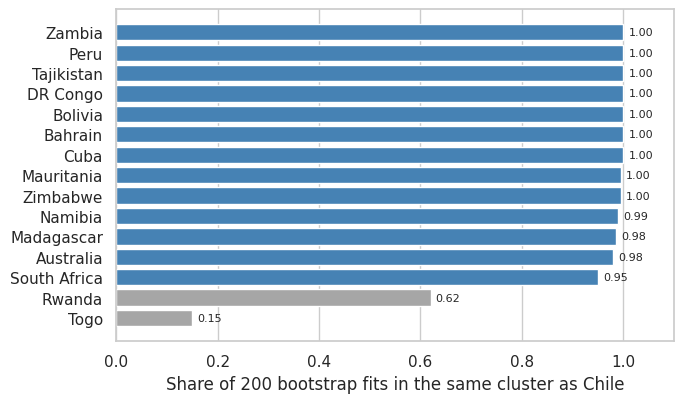

In [40]:
# Figure 11.7: how often each economy clusters with Chile
shown = together[together > 0.02].sort_values()
bar_names = sample.loc[shown.index, "country"].replace(
    {"Congo, Dem. Rep.": "DR Congo"})

fig, a = plt.subplots(figsize=(7, 4.2))
a.barh(bar_names, shown.values,
       color=[BLUE if v >= 0.9 else "0.65" for v in shown.values])
for y, v in enumerate(shown.values):
    a.text(v + 0.01, y, f"{np.round(v, 2):.2f}", va="center", fontsize=8)
a.set_xlim(0, 1.1)
a.set_xlabel("Share of 200 bootstrap fits in the same cluster as Chile")
a.grid(axis="y", visible=False)
plt.tight_layout()
plt.savefig("figures/fig11_7_cocluster_chile.png", dpi=200)
plt.show()

## 11.7 From Clusters to a Shortlist

### 11.7.1 The Metals Track

**Code Example 11.30** — The metals track: size, similarity and stability.

In [41]:
# Metals track: the rest of Chile's K-means cluster
metals_track = sample[(sample["group"] == "metals")
                      & ~sample.index.isin(["CHL", "PER"])]
track1 = pd.DataFrame({
    "gdp_bn": (metals_track["gdp_usd"] / 1e9).round(0),
    "similarity": similarity[metals_track.index].round(1),
    "with_chile": together[metals_track.index].round(2),
})
print(track1.sort_values("gdp_bn", ascending=False))

      gdp_bn  similarity  with_chile
iso3                                
AUS   1757.0        60.1        0.98
ZAF    401.0        59.1        0.95
CUB    107.0        87.8        1.00
COD     76.0        71.3        1.00
BOL     55.0        75.9        1.00
BHR     47.0        78.4        1.00
ZWE     42.0        65.6        1.00
ZMB     25.0        80.7        1.00
MDG     18.0        72.0        0.98
RWA     15.0        56.3        0.62
NAM     14.0        72.7        0.99
TJK     14.0        77.7        1.00
MRT     11.0        59.2        1.00


### 11.7.2 The Gold Track

**Code Example 11.31** — The gold track: checking the "other" cluster against mine production.

In [42]:
# Gold mine production, tonnes, latest year (USGS and BGS)
gold = pd.read_csv("ch11_gold_production.csv",
                   index_col="iso3")

# Gold track: the "other" cluster, checked against production
other = sample[sample["group5"] == "other"]
track2 = pd.DataFrame({
    "other_share": basket.loc[other.index,
                              "exp_other"].round(1),
    "gold_t": gold["gold_t"].reindex(other.index),
    "gdp_bn": (other["gdp_usd"] / 1e9).round(0),
})
track2["miner"] = track2["gold_t"] >= 20
print(track2.sort_values("gold_t", ascending=False))

      other_share  gold_t  gdp_bn  miner
iso3                                    
GHA          46.5  150.00    83.0   True
UZB          43.8  130.00   121.0   True
MLI          76.7   70.00    27.0   True
TZA          41.4   60.00    79.0   True
BFA          83.9   60.00    23.0   True
ARG          28.2   39.05   638.0   True
ZWE          34.0   32.13    42.0   True
KGZ          39.1   21.40    18.0   True
MRT          39.5   20.13    11.0   True
RWA          40.6   13.93    15.0  False
NAM          18.2    9.80    14.0  False
ARM          43.9    0.92    26.0  False
UGA          42.0    0.01    54.0  False
BLR          27.6    0.00    79.0  False


*Figure 11.8* (not printed in the book).

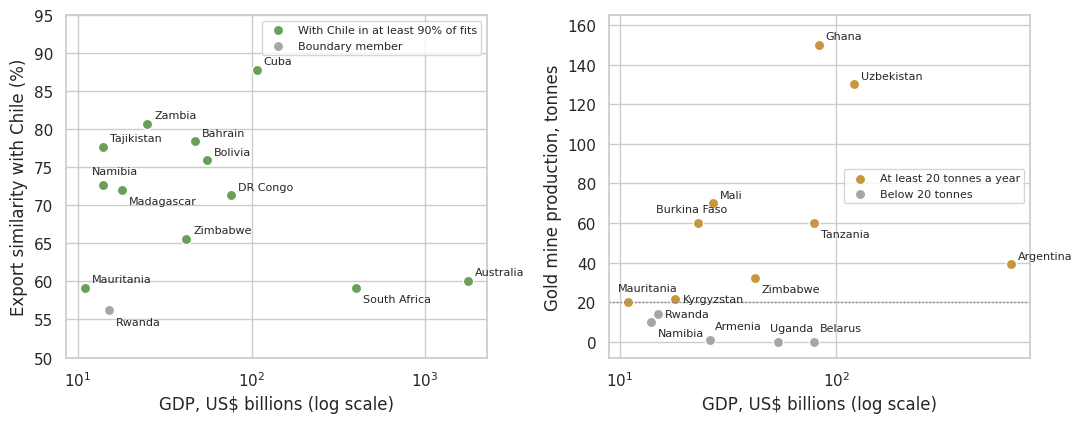

In [43]:
# Figure 11.8: the two tracks of the shortlist
GREEN, GOLD = "#6A9F58", "#C8963E"
nicer = {"Congo, Dem. Rep.": "DR Congo", "Kyrgyz Republic": "Kyrgyzstan"}
label_of = lambda iso: nicer.get(sample.loc[iso, "country"],
                                 sample.loc[iso, "country"])
fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))

# Left: metals track, similarity with Chile against GDP
firm = track1["with_chile"] >= 0.9
ax[0].scatter(track1.loc[firm, "gdp_bn"], track1.loc[firm, "similarity"],
              s=55, color=GREEN, edgecolor="white",
              label="With Chile in at least 90% of fits")
ax[0].scatter(track1.loc[~firm, "gdp_bn"],
              track1.loc[~firm, "similarity"], s=55, color="0.65",
              edgecolor="white", label="Boundary member")
off0 = {"MRT": (5, 4), "RWA": (5, -11), "ZAF": (5, -10),
        "NAM": (-8, 8), "MDG": (5, -10), "TJK": (5, 4)}
for iso in track1.index:
    ax[0].annotate(label_of(iso), (track1.loc[iso, "gdp_bn"],
                   track1.loc[iso, "similarity"]),
                   xytext=off0.get(iso, (5, 4)),
                   textcoords="offset points", fontsize=8)
ax[0].set_xscale("log")
ax[0].set_ylim(50, 95)
ax[0].set_xlabel(r"GDP, US\$ billions (log scale)")
ax[0].set_ylabel("Export similarity with Chile (%)")
ax[0].legend(loc="upper right", fontsize=8, frameon=True)

# Right: gold track, mine production against GDP
miner = track2["miner"]
ax[1].scatter(track2.loc[miner, "gdp_bn"], track2.loc[miner, "gold_t"],
              s=55, color=GOLD, edgecolor="white",
              label="At least 20 tonnes a year")
ax[1].scatter(track2.loc[~miner, "gdp_bn"],
              track2.loc[~miner, "gold_t"], s=55, color="0.65",
              edgecolor="white", label="Below 20 tonnes")
ax[1].axhline(20, color="0.5", ls=":", lw=1)
off1 = {"TZA": (5, -10), "BFA": (-30, 8), "MLI": (5, 4),
        "ZWE": (5, -10), "KGZ": (6, -2), "MRT": (-8, 8), "NAM": (5, -10),
        "RWA": (5, -2), "UGA": (-6, 8), "BLR": (4, 8), "ARM": (4, 8)}
for iso in track2.index:
    ax[1].annotate(label_of(iso), (track2.loc[iso, "gdp_bn"],
                   track2.loc[iso, "gold_t"]),
                   xytext=off1.get(iso, (5, 4)),
                   textcoords="offset points", fontsize=8)
ax[1].set_xscale("log")
ax[1].set_ylim(-8, 165)
ax[1].set_xlabel(r"GDP, US\$ billions (log scale)")
ax[1].set_ylabel("Gold mine production, tonnes")
ax[1].legend(loc="center right", fontsize=8, frameon=True)
plt.tight_layout()
plt.savefig("figures/fig11_8_two_tracks.png", dpi=200)
plt.show()